# BOOTSTRAP PROCEDURE : WHITE'S REALITY CHECK (WRC)

## Objectif du notebook

Ce notebook transforme le concept du **White's Reality Check** en expérience visuelle et codée.

L'idée centrale :

> Quand tu testes beaucoup de règles de trading, la meilleure règle du backtest peut être excellente uniquement parce qu'elle a eu de la chance.

Le WRC ne demande donc pas seulement :

> Est-ce que ma meilleure règle est profitable ?

Il demande :

> Dans un monde où toutes les règles sont nulles, est-ce que le hasard pourrait produire une meilleure règle aussi impressionnante que la mienne ?

C'est une différence énorme.


## 1. Le problème : le chercheur chanceux

Imagine que tu testes une seule stratégie.

Si elle fait un bon profit, tu peux te dire :

> Peut-être qu'elle a un edge.

Mais maintenant imagine que tu testes **1 000 variantes** :

- différents paramètres,
- différents horaires,
- différents filtres,
- différents actifs,
- différents stop-loss,
- différents take-profits.

Même si toutes ces règles sont nulles, certaines vont forcément sortir avec un beau résultat par hasard.

C'est le piège du **Data Mining Bias**.

Le WRC sert à répondre à cette question :

> Est-ce que ma meilleure règle bat vraiment le hasard, ou est-ce juste la meilleure survivante d'une grande loterie statistique ?


## 2. Les deux mondes

### Monde naïf

Tu regardes uniquement ta meilleure règle :

```text
Ma meilleure règle a gagné +0.08 % par jour.
Sa p-value classique est petite.
Donc elle est probablement bonne.
```

Problème : tu ignores toutes les autres règles testées avant de choisir celle-là.

---

### Monde WRC

Tu regardes tout l'univers de recherche :

```text
J'ai testé 1 000 règles.
Même si elles étaient toutes nulles, quelle performance maximale le hasard pourrait-il produire ?
Ma meilleure règle bat-elle ce maximum accidentel ?
```

Le WRC corrige donc le fait que tu as cherché longtemps avant de trouver une règle qui brille.


## 3. Intuition avec une loterie

Le WRC ressemble à une expérience mentale.

Tu organises 5 000 simulations.

Dans chaque simulation :

1. Toutes les règles sont supposées sans talent.
2. On les fait rejouer une histoire de marché artificielle.
3. On regarde la meilleure règle de cette simulation.
4. On garde seulement son score maximum.

À la fin, tu obtiens une distribution des **meilleurs scores que le hasard peut produire**.

Ensuite tu compares ta vraie meilleure règle à cette distribution.

Si ta règle ne dépasse pas clairement les records de chance, elle n'est pas validée.


## 4. Imports Python

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## 5. Créons un univers de règles de trading

On va simuler un backtest avec :

- `T = 750` jours de trading,
- `N = 500` règles candidates,
- la plupart des règles sont nulles,
- une seule règle possède un petit vrai edge.

L'objectif est de voir si le WRC arrive à distinguer le vrai edge du hasard.


In [2]:
T = 750       # nombre de jours
N = 1000       # nombre de règles testées

# Volatilité quotidienne simulée des rendements de stratégie
sigma = 0.01

# Univers de règles sans talent
returns = np.random.normal(loc=0.0, scale=sigma, size=(T, N))

# Ajoutons une règle avec un petit vrai edge
true_edge_rule = 17
daily_edge = 0.00045  # 0.045% par jour
returns[:, true_edge_rule] += daily_edge

df_returns = pd.DataFrame(
    returns,
    columns=[f"Rule_{i}" for i in range(N)]
)

df_returns.head()

,Rule_0,Rule_1,Rule_2,Rule_3,Rule_4,Rule_5,Rule_6,Rule_7,Rule_8,Rule_9,...,Rule_990,Rule_991,Rule_992,Rule_993,Rule_994,Rule_995,Rule_996,Rule_997,Rule_998,Rule_999
0,0.004967,-0.001383,0.006477,0.015230,-0.002342,-0.002341,0.015792,0.007674,-0.004695,0.005426,...,0.002084,-0.020417,-0.002472,-0.006820,-0.010016,-0.002811,0.017977,0.006408,-0.005712,0.005726
1,0.013994,0.009246,0.000596,-0.006469,0.006982,0.003935,0.008952,0.006352,0.010496,-0.005352,...,0.008004,0.007543,0.011889,0.007083,0.003514,0.010702,-0.000265,-0.008819,-0.001631,-0.007449
2,-0.006752,-0.001445,-0.007924,-0.003080,-0.018936,0.002133,0.000012,-0.008171,0.006592,0.009376,...,0.015164,0.006021,0.000720,-0.002122,-0.009519,0.000775,0.002578,-0.012418,0.003342,-0.001553
3,-0.019078,-0.008604,-0.004136,0.018877,0.005566,-0.013355,0.004860,-0.015473,0.010827,-0.004711,...,-0.016892,-0.004713,-0.019755,0.007511,-0.020651,0.000285,-0.020778,-0.003203,0.016434,0.003606
4,-0.008635,-0.000312,0.000180,0.004726,-0.013669,0.005926,-0.027044,-0.006299,-0.004883,0.006333,...,-0.020994,0.006832,-0.001148,0.005668,-0.006574,-0.000490,0.007114,0.031129,0.008080,-0.008481


## 6. Performance observée de chaque règle

On calcule la moyenne quotidienne de chaque règle sur le backtest.

Puis on identifie la meilleure règle observée.

Attention : la meilleure règle observée n'est pas forcément la meilleure vraie règle.

Elle peut simplement être celle qui a reçu le plus de chance dans l'échantillon.


In [3]:
mean_returns = df_returns.mean()
best_rule = mean_returns.idxmax()
best_observed_return = mean_returns.max()

print("Meilleure règle observée :", best_rule)
print("Rendement moyen quotidien observé :", round(best_observed_return, 6))
print("Règle avec vrai edge injecté :", f"Rule_{true_edge_rule}")
print("Rendement observé de la vraie règle :", round(mean_returns[f"Rule_{true_edge_rule}"], 6))

Meilleure règle observée : Rule_930
Rendement moyen quotidien observé : 0.000967
Règle avec vrai edge injecté : Rule_17
Rendement observé de la vraie règle : 0.000361


## 7. Visualiser le piège du maximum

Regardons toutes les performances moyennes observées.

Tu vas voir qu'une règle peut se détacher simplement parce qu'on en a testé beaucoup.


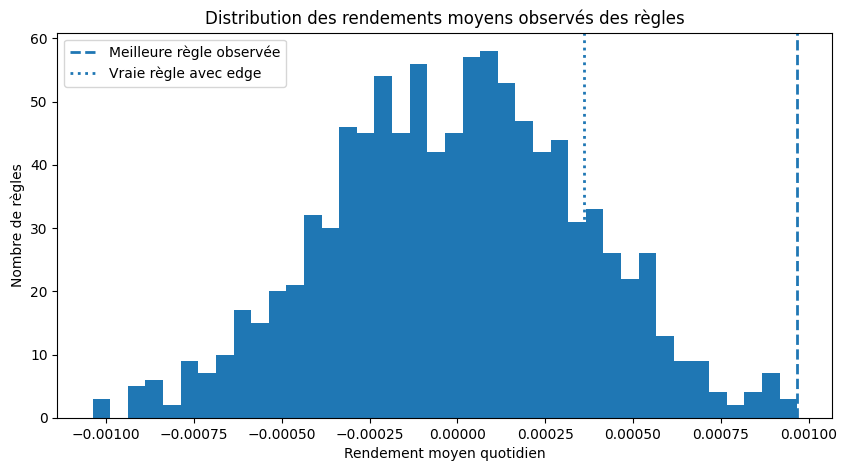

In [4]:
plt.figure(figsize=(10, 5))
plt.hist(mean_returns, bins=40)
plt.axvline(best_observed_return, linestyle="--", linewidth=2, label="Meilleure règle observée")
plt.axvline(mean_returns[f"Rule_{true_edge_rule}"], linestyle=":", linewidth=2, label="Vraie règle avec edge")
plt.title("Distribution des rendements moyens observés des règles")
plt.xlabel("Rendement moyen quotidien")
plt.ylabel("Nombre de règles")
plt.legend()
plt.show()

## 8. Le test naïf sur une seule règle

Un test classique regarde seulement la meilleure règle.

Il pose une question trop petite :

> Si cette règle seule était sans talent, son résultat serait-il rare ?

Mais il oublie une information capitale :

> Cette règle a été choisie parce qu'elle était la meilleure parmi 500.

Donc le test classique sous-estime le rôle de la chance.


In [5]:
# Test naïf approximatif : bootstrap d'une seule règle zéro-centrée

B = 5000
best_series = df_returns[best_rule].values
best_series_zero_centered = best_series - best_series.mean()

single_rule_boot_means = []

for _ in range(B):
    sample = np.random.choice(best_series_zero_centered, size=T, replace=True)
    single_rule_boot_means.append(sample.mean())

single_rule_boot_means = np.array(single_rule_boot_means)

naive_p_value = np.mean(single_rule_boot_means >= best_observed_return)

print("p-value naïve :", round(naive_p_value, 4))

p-value naïve : 0.0042


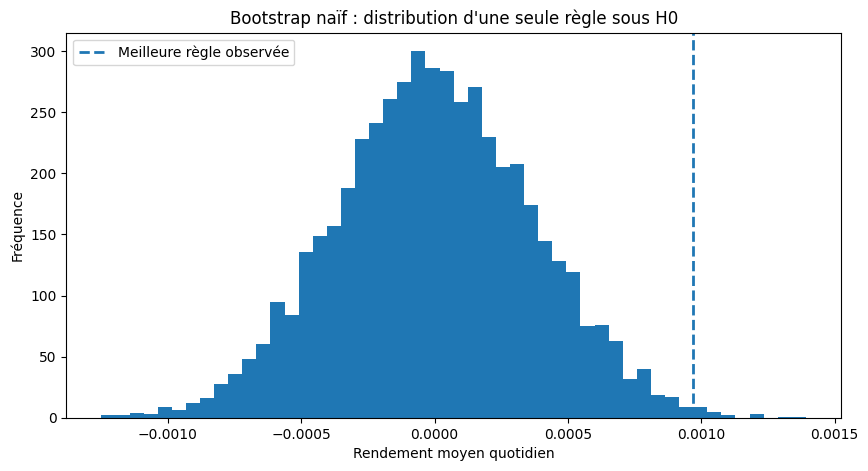

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(single_rule_boot_means, bins=50)
plt.axvline(best_observed_return, linestyle="--", linewidth=2, label="Meilleure règle observée")
plt.title("Bootstrap naïf : distribution d'une seule règle sous H0")
plt.xlabel("Rendement moyen quotidien")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

## 9. Pourquoi le test naïf est trop indulgent

Le graphique précédent compare ta meilleure règle à la chance d'une seule règle.

Mais en réalité, tu n'as pas joué une seule fois.

Tu as joué 500 fois.

Donc la vraie question n'est pas :

> Est-ce qu'une règle nulle peut faire aussi bien ?

La vraie question est :

> Est-ce que la meilleure parmi 500 règles nulles peut faire aussi bien ?

C'est exactement ce que fait le White's Reality Check.


## 10. Étape clé : le zéro-centrage individuel

Sous l'hypothèse nulle globale du WRC :

> Toutes les règles sont sans talent.

Donc on force chaque règle à avoir une moyenne de zéro.

Cela retire l'avantage observé de chaque règle, mais conserve :

- sa volatilité,
- sa forme de distribution,
- ses mauvais jours,
- ses bons jours,
- et surtout la structure commune entre les règles lorsqu'on rééchantillonne par dates.


In [7]:
# Zéro-centrage individuel de chaque règle
df_zero_centered = df_returns - df_returns.mean(axis=0)

print("Moyenne maximale après zéro-centrage :", df_zero_centered.mean().max())
print("Moyenne minimale après zéro-centrage :", df_zero_centered.mean().min())

Moyenne maximale après zéro-centrage : 1.6144493149757484e-18
Moyenne minimale après zéro-centrage : -1.7960170387946545e-18


## 11. Bootstrap WRC : rééchantillonnage par dates

Point ultra important :

On ne tire pas indépendamment les rendements de chaque règle.

On tire des **dates**.

Quand une date est tirée, on prend les rendements de toutes les règles ce jour-là.

Pourquoi ?

Parce que cela préserve la corrélation entre les règles.

Exemple :

- si un jour était très favorable aux stratégies trend-following,
- plusieurs règles peuvent gagner ce jour-là,
- cette relation doit être conservée dans le bootstrap.


In [8]:
wrc_boot_maxima = []

zero_values = df_zero_centered.values

for _ in range(B):
    sampled_dates = np.random.choice(np.arange(T), size=T, replace=True)

    # On prend les mêmes dates pour toutes les règles
    sampled_universe = zero_values[sampled_dates, :]

    # Moyenne bootstrap de chaque règle
    boot_rule_means = sampled_universe.mean(axis=0)

    # On garde seulement la meilleure performance de cette simulation
    wrc_boot_maxima.append(boot_rule_means.max())

wrc_boot_maxima = np.array(wrc_boot_maxima)

wrc_p_value = np.mean(wrc_boot_maxima >= best_observed_return)

print("p-value WRC :", round(wrc_p_value, 4))
print("p-value naïve :", round(naive_p_value, 4))

p-value WRC : 0.975
p-value naïve : 0.0042


## 12. Visualiser la distribution du maximum accidentel

Cette distribution est beaucoup plus exigeante que le bootstrap naïf.

Elle représente les meilleurs scores obtenus par hasard quand on teste 500 règles nulles.


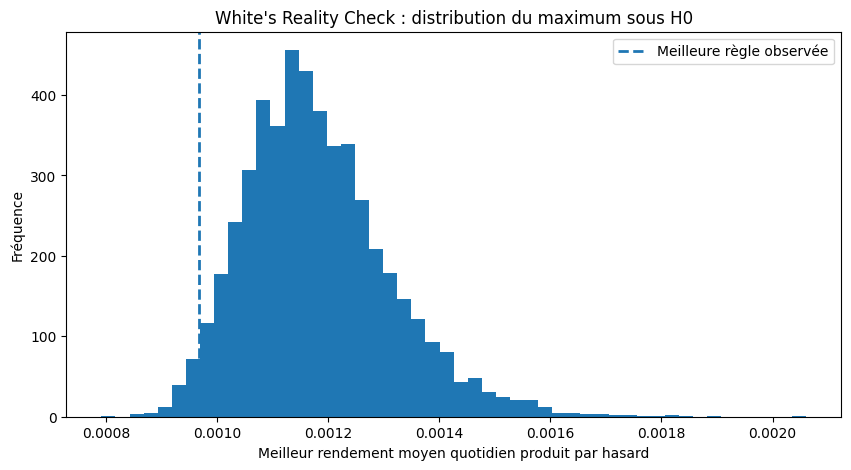

In [9]:
plt.figure(figsize=(10, 5))
plt.hist(wrc_boot_maxima, bins=50)
plt.axvline(best_observed_return, linestyle="--", linewidth=2, label="Meilleure règle observée")
plt.title("White's Reality Check : distribution du maximum sous H0")
plt.xlabel("Meilleur rendement moyen quotidien produit par hasard")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

## 13. Comparaison directe : test naïf vs WRC

Le test naïf compare ta règle à une seule règle chanceuse.

Le WRC compare ta règle au meilleur survivant d'un tournoi entier de règles nulles.

C'est pour cela que la p-value WRC est souvent beaucoup plus grande.


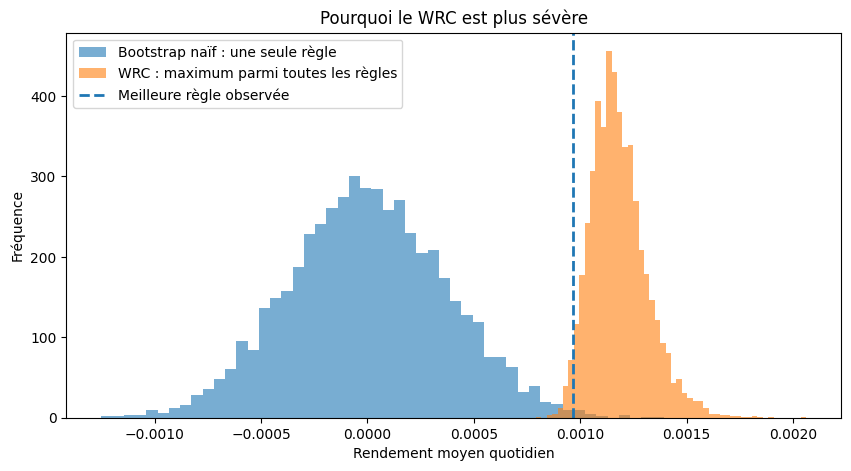

p-value naïve : 0.0042
p-value WRC   : 0.975


In [10]:
plt.figure(figsize=(10, 5))
plt.hist(single_rule_boot_means, bins=50, alpha=0.6, label="Bootstrap naïf : une seule règle")
plt.hist(wrc_boot_maxima, bins=50, alpha=0.6, label="WRC : maximum parmi toutes les règles")
plt.axvline(best_observed_return, linestyle="--", linewidth=2, label="Meilleure règle observée")
plt.title("Pourquoi le WRC est plus sévère")
plt.xlabel("Rendement moyen quotidien")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

print("p-value naïve :", round(naive_p_value, 4))
print("p-value WRC   :", round(wrc_p_value, 4))

## 14. Lecture EBTA du résultat

### Si la p-value naïve est faible mais la p-value WRC est élevée

Cela veut dire :

> La règle semble bonne quand on oublie le data mining, mais elle n'est pas exceptionnelle une fois qu'on tient compte de toutes les règles testées.

C'est typique d'une illusion statistique.

---

### Si la p-value WRC est faible

Cela veut dire :

> Même en comparant ta meilleure règle aux meilleurs résultats que le hasard peut produire dans tout l'univers de recherche, elle reste rare.

Là, tu as une preuve beaucoup plus sérieuse d'un possible edge.


## 15. Exemple avec différents nombres de règles

Plus tu testes de règles, plus le hasard peut produire une star artificielle.

On va répéter l'expérience en supposant que toutes les règles sont nulles, puis regarder la performance moyenne de la meilleure règle selon le nombre de règles testées.


In [11]:
def simulate_best_null_rule(T=750, N=100, sigma=0.01, experiments=1000):
    best_scores = []
    for _ in range(experiments):
        x = np.random.normal(0, sigma, size=(T, N))
        best_scores.append(x.mean(axis=0).max())
    return np.array(best_scores)

rule_counts = [1, 10, 50, 100, 500, 1000]
average_best_scores = []

for n_rules in rule_counts:
    scores = simulate_best_null_rule(T=T, N=n_rules, sigma=sigma, experiments=1000)
    average_best_scores.append(scores.mean())

comparison = pd.DataFrame({
    "Nombre de règles testées": rule_counts,
    "Meilleur rendement moyen attendu par hasard": average_best_scores
})

comparison

,Nombre de règles testées,Meilleur rendement moyen attendu par hasard
0,1,0.000002
1,10,0.000564
2,50,0.000829
3,100,0.000914
4,500,0.001116
5,1000,0.001181


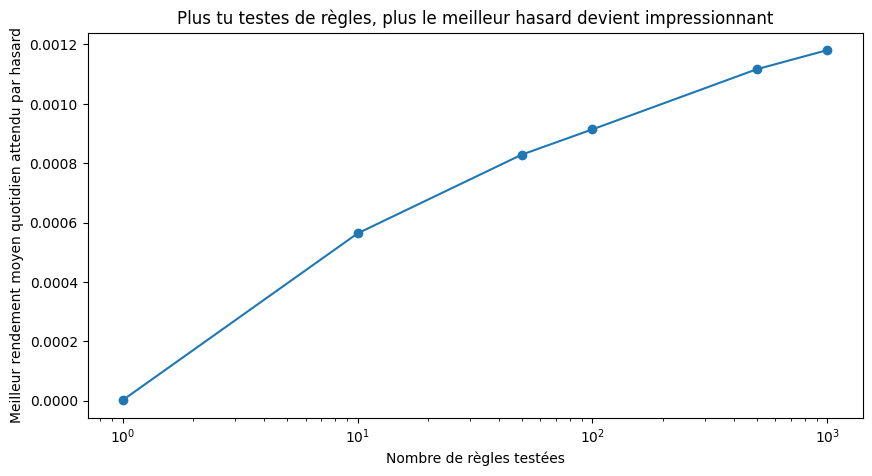

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(comparison["Nombre de règles testées"], comparison["Meilleur rendement moyen attendu par hasard"], marker="o")
plt.title("Plus tu testes de règles, plus le meilleur hasard devient impressionnant")
plt.xlabel("Nombre de règles testées")
plt.ylabel("Meilleur rendement moyen quotidien attendu par hasard")
plt.xscale("log")
plt.show()

## 16. Formule mentale à retenir

Le WRC transforme ton jugement.

### Avant WRC

```text
Ma meilleure règle gagne beaucoup.
Donc elle est probablement bonne.
```

### Après WRC

```text
Ma meilleure règle gagne beaucoup.
Mais est-ce beaucoup par rapport à ce que le meilleur hasard peut produire après 500 essais ?
```

C'est cette deuxième question qui protège ton capital.


## 17. Pseudo-code du WRC

```text
Entrée :
    Matrice des rendements : T jours x N règles

Étape 1 :
    Calculer la moyenne de chaque règle

Étape 2 :
    Identifier la meilleure règle réelle

Étape 3 :
    Zéro-centrer chaque règle :
        rendement_jour - moyenne_de_la_règle

Étape 4 :
    Répéter B fois :
        tirer T dates avec remise
        appliquer ces mêmes dates à toutes les règles
        calculer la moyenne bootstrap de chaque règle
        enregistrer la meilleure moyenne bootstrap

Étape 5 :
    p-value WRC =
        proportion des maxima bootstrap >= performance réelle de la meilleure règle
```


## 18. Fonction Python réutilisable

Voici une fonction simple que tu peux adapter à tes backtests.

Elle prend une matrice de rendements où :

- les lignes sont les dates,
- les colonnes sont les règles ou variantes testées.


In [13]:
def whites_reality_check(returns_df, n_boot=5000, seed=42):
    '''
    White's Reality Check simplifié.

    Parameters
    ----------
    returns_df : pd.DataFrame
        Rendements des règles.
        Lignes = dates.
        Colonnes = règles.
    n_boot : int
        Nombre d'itérations bootstrap.
    seed : int
        Graine aléatoire pour reproductibilité.

    Returns
    -------
    dict
        Résultat avec meilleure règle, performance observée,
        p-value WRC et distribution bootstrap des maxima.
    '''
    rng = np.random.default_rng(seed)

    T, N = returns_df.shape

    observed_means = returns_df.mean(axis=0)
    best_rule = observed_means.idxmax()
    best_perf = observed_means.max()

    zero_centered = returns_df - observed_means
    zero_values = zero_centered.values

    boot_maxima = np.empty(n_boot)

    for b in range(n_boot):
        sampled_idx = rng.choice(T, size=T, replace=True)
        sampled = zero_values[sampled_idx, :]
        boot_maxima[b] = sampled.mean(axis=0).max()

    p_value = np.mean(boot_maxima >= best_perf)

    return {
        "best_rule": best_rule,
        "best_observed_performance": best_perf,
        "wrc_p_value": p_value,
        "boot_maxima": boot_maxima
    }

result = whites_reality_check(df_returns, n_boot=5000, seed=123)

print("Meilleure règle :", result["best_rule"])
print("Performance observée :", round(result["best_observed_performance"], 6))
print("p-value WRC :", round(result["wrc_p_value"], 4))

Meilleure règle : Rule_930
Performance observée : 0.000967
p-value WRC : 0.9774


## 19. Interprétation pratique pour ton trading

Le WRC t'impose une discipline de chercheur sérieux.

Tu ne dois pas seulement conserver la règle gagnante.

Tu dois conserver toutes les règles testées.

Pourquoi ?

Parce que les mauvaises règles font partie du processus de recherche.

Si tu les supprimes, tu fais comme si tu n'avais joué qu'un seul ticket de loterie, alors qu'en réalité tu en as joué des centaines ou des milliers.


## 20. Actions concrètes EBTA

### 1. Journalise toutes les variantes

Quand tu testes des variantes de ton edge, garde une trace de toutes les configurations :

- paramètres,
- filtres,
- sessions,
- actifs,
- timeframes,
- conditions d'entrée,
- conditions de sortie.

### 2. Ne juge pas uniquement la meilleure courbe

La meilleure courbe est naturellement suspecte.

Elle contient :

```text
performance observée = edge réel + chance + biais de sélection
```

### 3. Compare toujours contre le maximum du hasard

La vraie validation n'est pas :

```text
Est-ce que ma règle est positive ?
```

Mais :

```text
Est-ce qu'elle bat ce que le hasard peut produire après la même quantité de recherche ?
```

### 4. Préserve la synchronisation des dates

Quand tu bootstrappes plusieurs règles, tire les dates, pas les rendements isolés.

Cela garde la structure commune du marché.


## 21. Conclusion EUREKA

Le White's Reality Check est difficile à accepter parce qu'il casse une illusion très séduisante :

> J'ai trouvé la meilleure règle, donc elle doit être spéciale.

Le WRC répond :

> Peut-être. Mais montre-moi qu'elle est spéciale même après avoir tenu compte de toutes les autres règles que tu as essayées.

C'est ça le cœur du concept.

Le WRC ne cherche pas à humilier ton backtest.

Il cherche à protéger ton capital contre les belles histoires produites par le hasard.
